В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Standard library
import sys
from typing import Tuple

# Third-party libraries
import numpy as np
import pandas as pd
import lightgbm as lgb
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Local application/library specific imports
sys.path.append('..')
from HW_2_3.process_bank_churn import preprocess_data, create_preprocessor, preprocess_new_data
from HW_2_3.custom_features import get_custom_pipelines
from HW_2_3.plot_utils import plot_roc_curve, print_main_metrics, plot_feature_importances

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [2]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
raw_df = pd.read_csv('../assets/hw_2_2/train.csv')

drop_cols = ['id', 'CustomerId', 'Surname', 'Exited']
input_cols = [col for col in raw_df.columns if col not in drop_cols]
target_col = 'Exited'

train_df, val_df = split_train_val(raw_df, target_col=target_col)

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

print("Train shape:", train_inputs.shape, train_targets.shape)
print("Val shape:", val_inputs.shape, val_targets.shape)
raw_df.head()

Train shape: (12000, 10) (12000,)
Val shape: (3000, 10) (3000,)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [4]:
categorical_cols = ['Geography', 'Gender', 'NumOfProducts']

for col in categorical_cols:
    train_inputs[col] = pd.Categorical(train_inputs[col])
    val_inputs[col] = pd.Categorical(val_inputs[col])

print(train_inputs.dtypes[categorical_cols])

Geography        category
Gender           category
NumOfProducts    category
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

Train AUROC: 0.9349
Validation AUROC: 0.9334


C:\Users\Dmity\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:729: UserWarning: [18:23:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


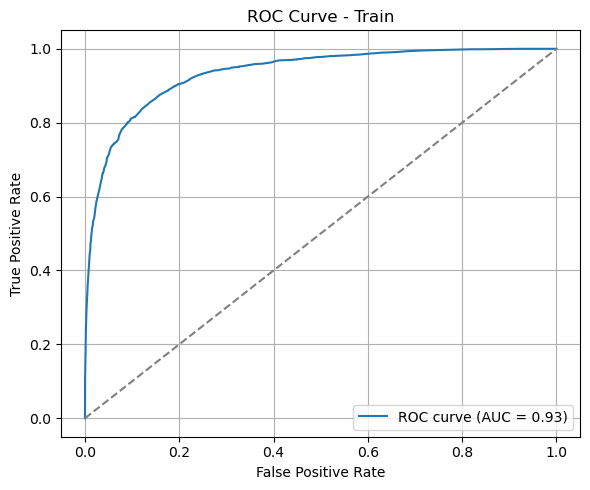

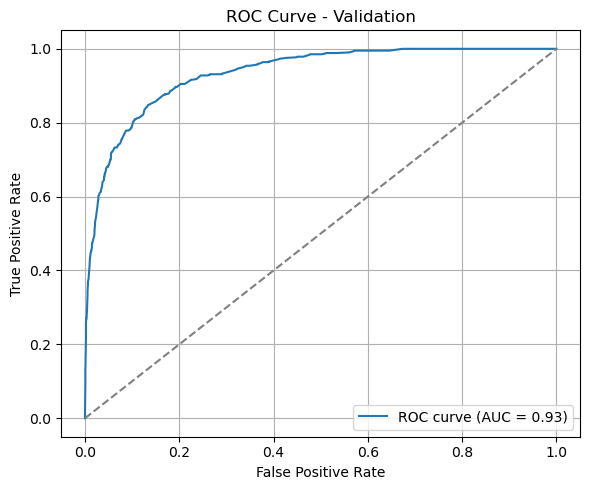

In [5]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,
    missing=np.nan,
    device='cuda'
)

xgb_clf.fit(train_inputs, train_targets)

train_preds_proba = xgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_proba = xgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_preds_proba)
val_auc = roc_auc_score(val_targets, val_preds_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

plot_roc_curve(train_targets, train_preds_proba, title="ROC Curve - Train")
plot_roc_curve(val_targets, val_preds_proba, title="ROC Curve - Validation")

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

100%|██████████| 20/20 [00:09<00:00,  2.21trial/s, best loss: -0.9363570889635778]
🔧 Best hyperparameters: {'colsample_bytree': 0.7660374925657433, 'gamma': 0.29607485901814845, 'learning_rate': 0.2569555426252916, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 225, 'reg_alpha': 0.5497102361783437, 'reg_lambda': 0.9868252866055883, 'subsample': 0.6438128826245918}
✅ Train AUROC: 0.9714
✅ Validation AUROC: 0.9238


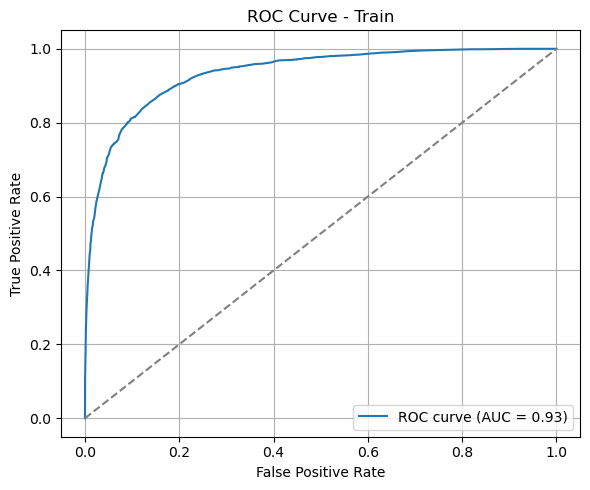

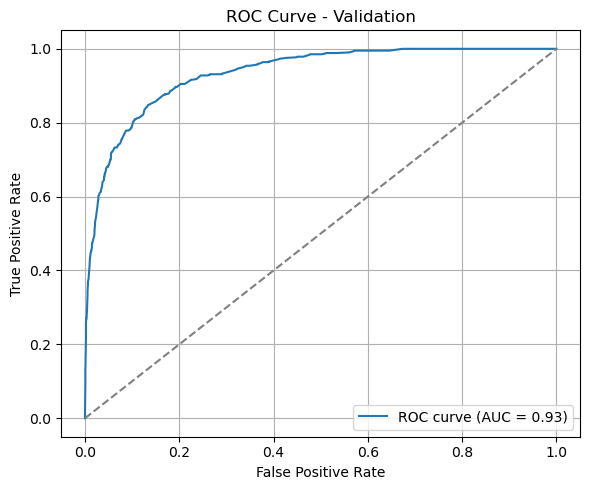

In [6]:
def objective(params):
    clf = XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        missing=np.nan,
        device='cuda',
        random_state=42,
        tree_method='hist',
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )

    val_preds = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_preds)

    return {'loss': -val_auc, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 12, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

trials = Trials()
best_xgb_params = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

best_xgb_params['n_estimators'] = int(best_xgb_params['n_estimators'])
best_xgb_params['max_depth'] = int(best_xgb_params['max_depth'])
best_xgb_params['min_child_weight'] = int(best_xgb_params['min_child_weight'])

print("🔧 Best hyperparameters:", best_xgb_params)

final_clf = XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    min_child_weight=best_xgb_params['min_child_weight'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    gamma=best_xgb_params['gamma'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state=42,
    tree_method='hist'
)

final_clf.fit(train_inputs, train_targets)

train_preds = final_clf.predict_proba(train_inputs)[:, 1]
val_preds = final_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_preds)
val_auc = roc_auc_score(val_targets, val_preds)

print(f"✅ Train AUROC: {train_auc:.4f}")
print(f"✅ Validation AUROC: {val_auc:.4f}")

plot_roc_curve(train_targets, train_preds_proba, title="ROC Curve - Train")
plot_roc_curve(val_targets, val_preds_proba, title="ROC Curve - Validation")

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 842
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

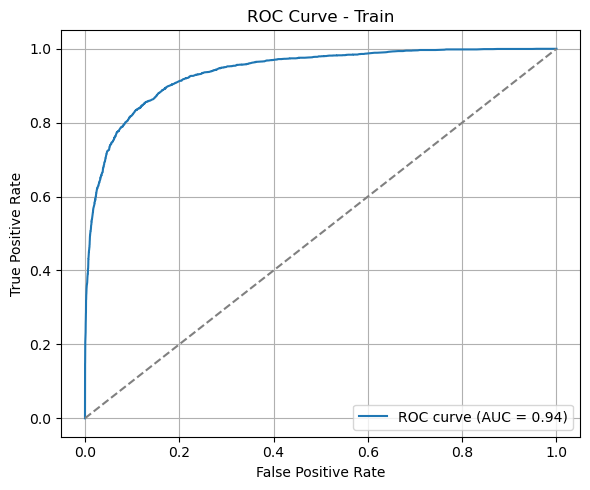

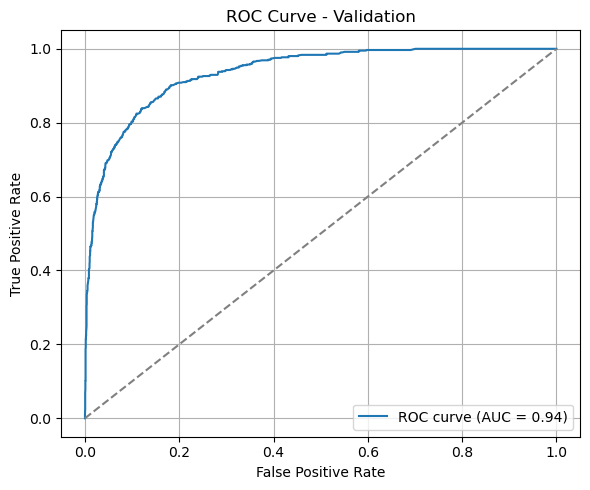

In [7]:
cat_feature_indexes = [
    train_inputs.columns.get_loc(col)
    for col in train_inputs.select_dtypes(include="category").columns
]

lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    missing=np.nan,
    random_state=42
)

lgb_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric="auc",
    categorical_feature=cat_feature_indexes,
)

train_preds_proba = lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_proba = lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_preds_proba)
val_auc = roc_auc_score(val_targets, val_preds_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

plot_roc_curve(train_targets, train_preds_proba, title="ROC Curve - Train")
plot_roc_curve(val_targets, val_preds_proba, title="ROC Curve - Validation")

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 842                      
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561 
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

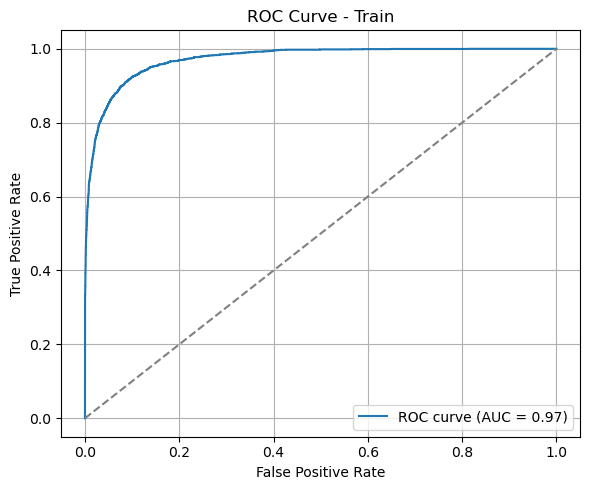

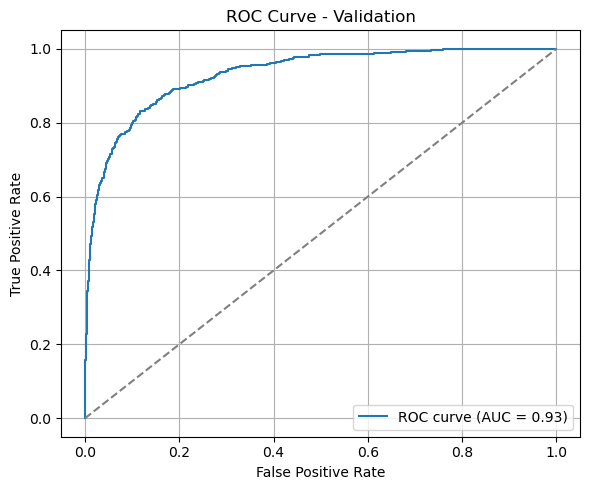

In [8]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        min_split_gain=params['min_split_gain'],
        random_state=42
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric='auc',
        categorical_feature=cat_feature_indexes,
        callbacks=[lgb.early_stopping(stopping_rounds=10)]
    )

    preds_proba = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, preds_proba)

    return {'loss': -auc, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 12, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0),
    'min_split_gain': hp.uniform('min_split_gain', 0.0, 0.1)
}

trials = Trials()
best_lgb_params = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

best_lgb_params['n_estimators'] = int(best_lgb_params['n_estimators'])
best_lgb_params['max_depth'] = int(best_lgb_params['max_depth'])
best_lgb_params['num_leaves'] = int(best_lgb_params['num_leaves'])
best_lgb_params['min_child_weight'] = int(best_lgb_params['min_child_weight'])

print("Best hyperparameters:", best_lgb_params)

final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best_lgb_params['n_estimators'],
    learning_rate=best_lgb_params['learning_rate'],
    max_depth=best_lgb_params['max_depth'],
    num_leaves=best_lgb_params['num_leaves'],
    min_child_weight=best_lgb_params['min_child_weight'],
    subsample=best_lgb_params['subsample'],
    colsample_bytree=best_lgb_params['colsample_bytree'],
    reg_alpha=best_lgb_params['reg_alpha'],
    reg_lambda=best_lgb_params['reg_lambda'],
    min_split_gain=best_lgb_params['min_split_gain'],
    random_state=42
)

final_lgb_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric='auc',
    categorical_feature=cat_feature_indexes
)

train_preds_proba = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_proba = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_preds_proba)
val_auc = roc_auc_score(val_targets, val_preds_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

plot_roc_curve(train_targets, train_preds_proba, title="ROC Curve - Train")
plot_roc_curve(val_targets, val_preds_proba, title="ROC Curve - Validation")

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [11]:
test_raw_df = pd.read_csv("../assets/hw_2_2/test.csv")
submission_df = pd.read_csv("../assets/hw_2_2/sample_submission.csv")

drop_cols = ["id", "CustomerId", "Surname", "Exited"]
input_cols_all = [col for col in raw_df.columns if col not in drop_cols]

X_all = raw_df[input_cols_all].copy()
y_all = raw_df["Exited"]

for col in X_all.select_dtypes(include='object').columns:
    X_all[col] = X_all[col].astype('category')
for col in test_raw_df.select_dtypes(include='object').columns:
    test_raw_df[col] = test_raw_df[col].astype('category')

X_test_processed = test_raw_df[input_cols_all].copy()

# ====== XGBoost Best Model ======
xgb_best = XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    min_child_weight=best_xgb_params['min_child_weight'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    gamma=best_xgb_params['gamma'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    tree_method="hist",
    device="cuda",
    random_state=42
)
xgb_best.fit(X_all, y_all)
xgb_preds = xgb_best.predict(X_test_processed)
xgb_preds_proba = xgb_best.predict_proba(X_test_processed)[:, 1]

submission_xgb = submission_df.copy()
submission_xgb_proba = submission_df.copy()
submission_xgb["Exited"] = xgb_preds
submission_xgb_proba["Exited"] = xgb_preds_proba
submission_xgb.to_csv("../assets/hw_2_4/submission_xgb_hyperopt.csv", index=False)
submission_xgb_proba.to_csv("../assets/hw_2_4/submission_xgb_hyperopt_proba.csv", index=False)

# ====== LightGBM Best Model ======
lgb_best = lgb.LGBMClassifier(
    n_estimators=best_lgb_params['n_estimators'],
    learning_rate=best_lgb_params['learning_rate'],
    max_depth=best_lgb_params['max_depth'],
    num_leaves=best_lgb_params['num_leaves'],
    min_child_weight=best_lgb_params['min_child_weight'],
    subsample=best_lgb_params['subsample'],
    colsample_bytree=best_lgb_params['colsample_bytree'],
    reg_alpha=best_lgb_params['reg_alpha'],
    reg_lambda=best_lgb_params['reg_lambda'],
    min_split_gain=best_lgb_params['min_split_gain'],
    random_state=42
)
lgb_best.fit(X_all, y_all, categorical_feature=cat_feature_indexes)

lgb_preds = lgb_best.predict(X_test_processed)
lgb_preds_proba = lgb_best.predict_proba(X_test_processed)[:, 1]

submission_lgb = submission_df.copy()
submission_lgb_proba = submission_df.copy()
submission_lgb["Exited"] = lgb_preds
submission_lgb_proba["Exited"] = lgb_preds_proba
submission_lgb.to_csv("../assets/hw_2_4/submission_lgb_hyperopt.csv", index=False)
submission_lgb_proba.to_csv("../assets/hw_2_4/submission_lgb_hyperopt_proba.csv", index=False)

display(submission_xgb.head())
display(submission_xgb_proba.head())
display(submission_lgb.head())
display(submission_lgb_proba.head())

[LightGBM] [Info] Number of positive: 3052, number of negative: 11948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203467 -> initscore=-1.364767
[LightGBM] [Info] Start training from score -1.364767


,id,Exited
0,15000,0
1,15001,0
2,15002,0
3,15003,1
4,15004,0


,id,Exited
0,15000,0.054826
1,15001,0.018405
2,15002,0.036041
3,15003,0.631911
4,15004,0.040179


,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0


,id,Exited
0,15000,0.118807
1,15001,0.014791
2,15002,0.044229
3,15003,0.645772
4,15004,0.031068
